In [1]:
import pyvinecopulib as pvc
import pickle as pkl
import json
from models.VineCopula import get_family_counts
import pandas as pd
from tools.Portfolio import mu as mu_pf
from backtest import Backtest
from tools.Plotting import plot_vine, Theme
import matplotlib.pyplot as plt

Theme.set_theme("scientific")

## Vines

In [11]:
p = 10
md = "StudentsT"
folder = "ItauTailTruncT" #"GaussianTrunc25" #"Asym" # 00, 01, etc.

base = f"data/{p}/Garch/Normal/VineCopula/{md}/"
if folder:
    path = base+folder+"/"
else:
    path = base

with open(path+"models.pkl","rb") as f:
    vine_results = pkl.load(f)

returns = pd.read_parquet(f"data/{p}/portfolio_returns.parquet")
mu = mu_pf(returns)

var = pd.read_parquet(path+"VaR.parquet")
es = pd.read_parquet(path+"ES.parquet")

path

'data/10/Garch/Normal/VineCopula/StudentsT/ItauTailTruncT/'

In [12]:
with open(path+"params.json","rb") as f:
    params = json.load(f)
print(json.dumps(params, indent=2))

{
  "portfolio": 10,
  "volatility": {
    "mean_model": "ConstantMean",
    "volatility_model": "Garch",
    "innovation_distribution": "Normal"
  },
  "simulation": {
    "name": "VineCopula",
    "margin_distribution": "StudentsT",
    "f0": 3,
    "n": 10000,
    "alpha": 0.01,
    "risk_metric": [
      "VaR",
      "ES"
    ],
    "window_size": 250
  },
  "calculation": {
    "from": 0,
    "to": null,
    "save_freq": 250,
    "max_workers": 8,
    "runtime": 1882.923425727
  },
  "controls": {
    "allow_rotations": true,
    "family_set": [
      "gaussian",
      "student",
      "clayton",
      "gumbel",
      "joe",
      "frank"
    ],
    "nonparametric_grid_size": 30,
    "nonparametric_method": "constant",
    "nonparametric_mult": 1.0,
    "num_threads": 0,
    "parametric_method": "itau",
    "preselect_families": true,
    "psi0": 0.9,
    "select_families": true,
    "select_threshold": false,
    "select_trunc_lvl": false,
    "selection_criterion": "mbicv",
    

In [13]:
# Failure rate
violations = Backtest.simple_hits(mu, var)
Backtest.failure_rate(violations)

np.float64(0.009038199181446112)

In [14]:
vine_results

{0: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 250: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 500: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 750: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 1000: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 1250: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 1500: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 1750: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 2000: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 2250: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 2500: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 2750: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 3000: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 3250: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 3500: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 3750: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 4000: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 4250: VineCopula(dim=10,trunc_lvl=3,threshold=0.05),
 4500: VineCopula(dim=10,trunc_lvl

In [15]:
# Average number of families over all windows and trees 
total = {}
for idx, obj in vine_results.items():
    vine = obj.vine
    families = get_family_counts(vine, how="total")
    for fam, count in families.items():
        if fam in total:
            total[fam] += count
        else:
            total[fam] = count

avg = {fam: round(count/len(vine_results),2) for fam, count in total.items()}
avg

{'frank': 8.25,
 'gaussian': 3.29,
 'indep': 2.71,
 'gumbel': 6.29,
 'clayton': 1.79,
 'joe': 1.08,
 'student': 0.58}

In [16]:
# Average number of families per tree 
total = {}
for idx, obj in vine_results.items():
    vine = obj.vine
    trees = get_family_counts(vine, how="tree")
    for lvl, family_dict in trees.items():
        if lvl not in total:
            total[lvl] = {}
        for fam, count in family_dict.items():
            if fam in total[lvl].keys():
                total[lvl][fam] += count
            else:
                total[lvl][fam] = count

avg = {lvl: {fam: round(count/len(vine_results),2) for fam, count in families.items()} for lvl, families in total.items()}
avg

{0: {'joe': 0.12,
  'frank': 3.42,
  'gumbel': 3.08,
  'gaussian': 1.79,
  'clayton': 0.29,
  'student': 0.29},
 1: {'indep': 0.67,
  'gumbel': 2.0,
  'gaussian': 0.96,
  'frank': 2.92,
  'joe': 0.42,
  'clayton': 0.88,
  'student': 0.17},
 2: {'indep': 2.04,
  'gaussian': 0.54,
  'frank': 1.92,
  'clayton': 0.62,
  'gumbel': 1.21,
  'joe': 0.54,
  'student': 0.12}}

In [44]:
# Copula rotations, {degree: count}
# Info: 90°, 270° mean no tail-dependence, but a negative (asymmetric) dependence in the tail, e.g. one rises while the other falls

family = "gumbel"

rotations = {}
for vine_result in vine_results.values():
    vine = vine_result.vine
    for tree in range(vine.dim-1):
        for bcop in vine.pair_copulas[tree]:
            if bcop.family.name == family:
                rotations[bcop.rotation] = rotations.get(bcop.rotation, 0) + 1
for deg, count in rotations.items():
    rotations[deg] = count / len(vine_results)
rotations

{0: 4.666666666666667,
 180: 4.666666666666667,
 270: 1.7083333333333333,
 90: 1.7916666666666667}

In [78]:
# Inspecting the tree structure change
# Window-wise average weighted Jaccard distance vs. peer

from stats.Jaccard import VineStructureSnapshot
import numpy as np

p = 10
folder0 = "ItauTailTailtauTrunc"
folder1 = "ItauTailTailtauTruncThresh"

base = f"data/{p}/Garch/Normal/VineCopula/Empirical/"
if folder0:
    path0 = base+folder0+"/"
if folder1:
    path1 = base+folder1+"/"
else:
    path = base

with open(path0+"models.pkl","rb") as f:
    vine_results0 = pkl.load(f)

with open(path1+"models.pkl","rb") as f:
    vine_results1 = pkl.load(f)

snaps0 = [VineStructureSnapshot.from_vinecop(obj.vine) for obj in vine_results0.values()]
snaps1 = [VineStructureSnapshot.from_vinecop(obj.vine) for obj in vine_results1.values()]

dists = [snap0.weighted_jaccard_distance(snap1) for snap0, snap1 in zip(snaps0, snaps1)]

np.mean(dists), np.min(dists), np.max(dists)

(np.float64(0.9309586988992997),
 np.float64(0.7137265865250209),
 np.float64(1.0))

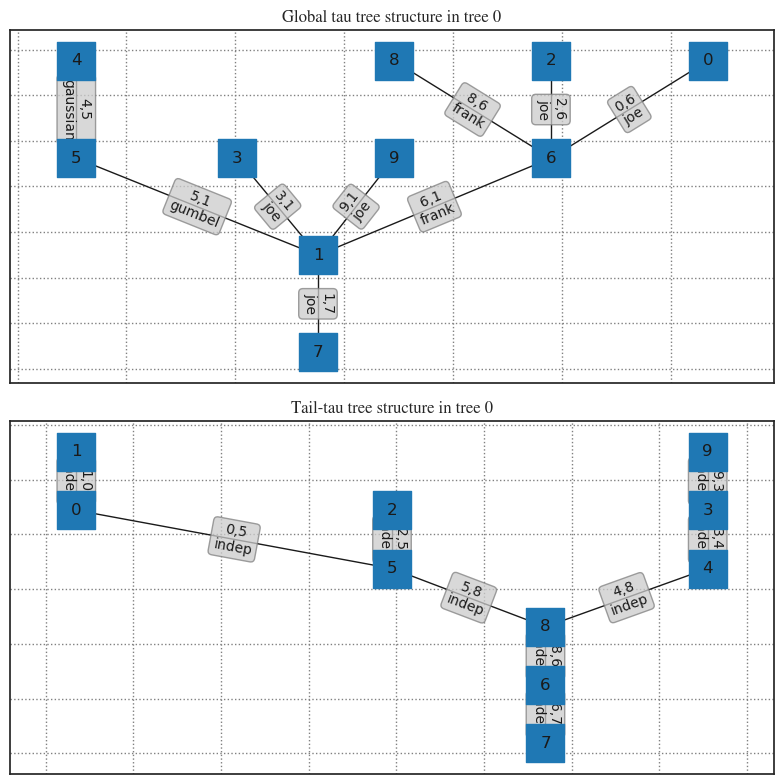

In [79]:
# Inspecting the first tree in a given window

win_idx = 250

vine0, vine1 = vine_results0[win_idx].vine, vine_results1[win_idx].vine

fig, axs = plt.subplots(nrows=2, figsize=(8,8))

plot_vine(vine0,[0], ax=axs[0])
plot_vine(vine1,[0], ax=axs[1])

axs[0].set_title("Global tau tree structure in tree 0")
axs[1].set_title("Tail-tau tree structure in tree 0")

plt.tight_layout()
plt.show()

In [80]:
# Show common edges in tree 0

from tools.Helpers import get_common_edges

get_common_edges(vine0, vine1, 0)

{(frozenset({6, 8}), frozenset())}

In [57]:
# Extract a pair copula from a given vine, conditioned on a specific edge

from tools.Helpers import get_pair_copula

common_edge = (1,5)

t0,e0, cop0 = get_pair_copula(vine0, conditioned=common_edge)
t1,e1, cop1 = get_pair_copula(vine1, conditioned=common_edge)

cop0, cop1

(<pyvinecopulib.Bicop> Bivariate copula: 
   family = Gumbel
   rotation = 180
   var_types = c,c
   parameters = 1.1,
 <pyvinecopulib.Bicop> Bivariate copula: 
   family = Gumbel
   rotation = 180
   var_types = c,c
   parameters = 1.1)

In [58]:
# Inspecting copula-implied analytical Kendall's taus

# A large gap between the model-implied tau (analytical form for a copula, e.g. \tau = 1 - 4/(theta+2) for Clayton)
# and the empirical tail-tau (data-only) on a given edge means the fitted family is summarising 
# a tail-concentrated dependence with a global parameter that understates the tail signal. 
# If you rank edges by this gap, the ones with the largest discrepancy are precisely 
# where family misspecification is most likely to contribute to quantile drift — a potentially 
# clean diagnostic result.

vine0.taus[t0][e0], vine1.taus[t1][e1] # global model-implied (analytical) tau

(0.10331546355879244, 0.10331546355879244)

In [60]:
# Comparing empirical (data) global tau vs. empirical tail-tau

import models.AdjustedReturn as AdjustedReturn
from models.VineCopula import threshold_kendalls_tau
from scipy.stats import kendalltau

returns = pd.read_parquet(f"data/{p}/portfolio_returns.parquet")
volatilities = pd.read_parquet(f"data/{p}/Garch/Normal/volatility_forecasts.parquet")

_, adj_r_windows = AdjustedReturn.adjusted_return_windows(returns, volatilities)

# Adjusted Returns in window
adj_r = adj_r_windows[win_idx]
pobs = pvc.to_pseudo_obs(adj_r)

# Global Kendall tau of assets (a,b)
u, v = pobs[:,common_edge[0]], pobs[:,common_edge[1]]
tau, _ = kendalltau(u, v)

# Tail-tau of assets (a,b)
tail_tau = threshold_kendalls_tau(u, v, threshold=0.25, tail="lower")

tau, tail_tau

(np.float64(0.10331546355879259), np.float64(0.3684210526315789))

In [123]:
# Running the tail-tau vine copula simulation manually for the given window
#
#from simulations.VineCopula import simulate_vc_tailtau
#
#controls = pvc.FitControlsVinecop(
#    family_set=[pvc.indep, pvc.joe], 
#    parametric_method="itau",
#    selection_criterion="mbicv",
#    select_threshold=True,
#    trunc_lvl=25)
#
#res, var, es = simulate_vc_tailtau(adj_r, controls, "Empirical", tau_tails="lower", tau_threshold=0.25)
#
#fig, ax = plt.subplots(figsize=(8,4))
#plot_vine(res.vine, [0], ax=ax)

In [71]:
# Kendalls tau matrix vs. Tail-tau matrix

from IPython.display import display, Markdown
import seaborn as sns
from itertools import combinations

df = pd.DataFrame(pobs)
df_tau = df.corr(method="kendall").abs().round(2)

def compute_tail_tau_matrix(data):
    d = data.shape[1]
    matrix = np.ones((d, d))
    for i, j in combinations(range(d), 2):
        tau = threshold_kendalls_tau(data[:, i], data[:, j], threshold=0.25, tail="lower")
        matrix[i, j] = matrix[j, i] = np.abs(tau)
    return matrix

tail_tau_matrix = compute_tail_tau_matrix(pobs)
df_tail_tau = pd.DataFrame(tail_tau_matrix)


#def func(u,v):
#    return threshold_kendalls_tau(u, v, threshold=0.25, tail="lower")
#df_tail_tau = df.corr(method=func).abs().round(2)


#fig, axs = plt.subplots(ncols=2, figsize=(8,5),sharey = True)
#sns.heatmap(df_tau, annot=True, fmt=".2f", ax=axs[0],cbar=False)
#axs[0].set_title("Kendall's tau matrix")
#sns.heatmap(df_tail_tau, annot=True, fmt=".2f", ax=axs[1],cbar=False)
#axs[1].set_title("Tail-tau matrix")

#plt.tight_layout()
#plt.show()

display(Markdown("**Kendall's $|\\tau|$ matrix** in tree 0"))
display(df_tau.style.format("{:.2f}").background_gradient())
display(Markdown("**Tail-$|\\tau|$ matrix in tree 0**"))
display(df_tail_tau.style.format("{:.2f}").background_gradient())

**Kendall's $|\tau|$ matrix** in tree 0

,0,1,2,3,4,5,6,7,8,9
0,1.00,0.08,0.07,0.05,0.20,0.26,0.11,0.04,0.20,0.10
1,0.08,1.00,0.07,0.07,0.10,0.10,0.00,0.02,0.02,0.04
2,0.07,0.07,1.00,0.04,0.01,0.17,0.01,0.08,0.05,0.02
3,0.05,0.07,0.04,1.00,0.17,0.09,0.09,0.07,0.12,0.07
4,0.20,0.10,0.01,0.17,1.00,0.28,0.12,0.14,0.23,0.14
5,0.26,0.10,0.17,0.09,0.28,1.00,0.17,0.15,0.32,0.17
6,0.11,0.00,0.01,0.09,0.12,0.17,1.00,0.07,0.12,0.16
7,0.04,0.02,0.08,0.07,0.14,0.15,0.07,1.00,0.22,0.14
8,0.20,0.02,0.05,0.12,0.23,0.32,0.12,0.22,1.00,0.19
9,0.10,0.04,0.02,0.07,0.14,0.17,0.16,0.14,0.19,1.00


**Tail-$|\tau|$ matrix in tree 0**

,0,1,2,3,4,5,6,7,8,9
0,1.00,0.18,0.04,0.08,0.02,0.12,0.26,0.24,0.10,0.11
1,0.18,1.00,0.12,0.30,0.09,0.37,0.35,0.25,0.07,0.44
2,0.04,0.12,1.00,0.19,0.03,0.15,0.50,0.01,0.04,0.03
3,0.08,0.30,0.19,1.00,0.09,0.00,0.07,0.23,0.02,0.28
4,0.02,0.09,0.03,0.09,1.00,0.30,0.20,0.03,0.12,0.20
5,0.12,0.37,0.15,0.00,0.30,1.00,0.30,0.10,0.17,0.08
6,0.26,0.35,0.50,0.07,0.20,0.30,1.00,0.14,0.17,0.08
7,0.24,0.25,0.01,0.23,0.03,0.10,0.14,1.00,0.01,0.08
8,0.10,0.07,0.04,0.02,0.12,0.17,0.17,0.01,1.00,0.10
9,0.11,0.44,0.03,0.28,0.20,0.08,0.08,0.08,0.10,1.00


In [134]:
# Plot a vine tree for a given window

window = 0

#fig, ax = plt.subplots(figsize=(8,5))
#plot_vine(vine_results[window].vine, trees=[0,1], ax=ax, layout="graphviz")

#plt.show()

In [ ]:
# Export pyvis HTML network chart

from tools.Graphs import make_graph_network, make_network_html

window = 0
vine = vine_results[window].vine

G = make_graph_network(vine)

make_network_html(G, filename=f"vine_structure_{window}.html")

## Multivariate Copula

In [54]:
p = 100
copula = "Student"
folder = None

base = f"data/{p}/Garch/Normal/MultivariateCopula/{copula}/Empirical/"
if folder:
    path = base+folder+"/"
else:
    path = base

with open(path+"models.pkl","rb") as f:
    vine_results = pkl.load(f)

returns = pd.read_parquet(f"data/{p}/portfolio_returns.parquet")
mu = mu_pf(returns)

var = pd.read_parquet(path+"VaR.parquet")
es = pd.read_parquet(path+"ES.parquet")

path

'data/100/Garch/Normal/MultivariateCopula/Student/Empirical/'

In [55]:
# Failure rate
violations = Backtest.simple_hits(mu, var)
Backtest.failure_rate(violations)

np.float64(0.008356070941336972)

## Variance Covariance

In [37]:
p = 500
folder = "Student"

base = f"data/{p}/Garch/Normal/VarianceCovariance/"
if folder:
    path = base+folder+"/"
else:
    path = base


returns = pd.read_parquet(f"data/{p}/portfolio_returns.parquet")
mu = mu_pf(returns)

var = pd.read_parquet(path+"VaR.parquet")
es = pd.read_parquet(path+"ES.parquet")

path

'data/500/Garch/Normal/VarianceCovariance/Student/'

In [38]:
# Failure rate
violations = Backtest.simple_hits(mu, var)
Backtest.failure_rate(violations)

np.float64(0.011596180081855388)

## Historical Simulation

In [17]:
p = 500
folder = None

path = f"data/{p}/Garch/Normal/HistoricalSimulation/"

returns = pd.read_parquet(f"data/{p}/portfolio_returns.parquet")
mu = mu_pf(returns)

var = pd.read_parquet(path+"VaR.parquet")
es = pd.read_parquet(path+"ES.parquet")

path

'data/500/Garch/Normal/HistoricalSimulation/'

In [18]:
# Failure rate
violations = Backtest.simple_hits(mu, var)
Backtest.failure_rate(violations)

np.float64(0.012107776261937243)